# Classical classification of computing publications

This notebook runs the classical part of the final project. 

TF-IDF models are trained for Field and Methodology classification, by using the fixed project datasets and partitions.

Discipline is obtained from the predicted Field through the saved hierarchy.

In [1]:
from pathlib import Path
import json

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

DATA_DIR = Path("Data")
SPLIT_DIR = DATA_DIR / "Splits"

SUBJECT_PATH = DATA_DIR / "Subject Data.csv"
METHODOLOGY_PATH = DATA_DIR / "Methodology Data.csv"
HIERARCHY_PATH = DATA_DIR / "Field Discipline Map.json"

SUBJECT_SPLIT_PATH = SPLIT_DIR / "Subject Split.csv"
METHODOLOGY_SPLIT_PATH = SPLIT_DIR / "Methodology Split.csv"

RESULTS_DIR = Path("Results") / "Classical"
FIGURE_DIR = RESULTS_DIR / "Figures"
PREDICTION_DIR = RESULTS_DIR / "Predictions"
REPORT_DIR = RESULTS_DIR / "Reports"
MODEL_DIR = Path("Models") / "Classical"

for folder in (
    RESULTS_DIR,
    FIGURE_DIR,
    PREDICTION_DIR,
    REPORT_DIR,
    MODEL_DIR,
):
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)

## Final datasets and taxonomy

Subject dataset contains 400 publications, in eight Fields and four Disciplines.

Methodology dataset contains 450 publications in six classes. 

The saved split files and Field-to-Discipline map are loaded with the data.

Consistency checks run before the modelling starts.

In [2]:
required_paths = (
    SUBJECT_PATH,
    METHODOLOGY_PATH,
    HIERARCHY_PATH,
    SUBJECT_SPLIT_PATH,
    METHODOLOGY_SPLIT_PATH,
)

missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("\n".join(str(path) for path in missing_paths))

subject_df = pd.read_csv(SUBJECT_PATH)
method_df = pd.read_csv(METHODOLOGY_PATH)
subject_split = pd.read_csv(SUBJECT_SPLIT_PATH)
method_split = pd.read_csv(METHODOLOGY_SPLIT_PATH)

with HIERARCHY_PATH.open("r", encoding="utf-8") as f:
    field_to_discipline = json.load(f)

for frame in (subject_df, method_df, subject_split, method_split):
    frame["paper_id"] = frame["paper_id"].astype(str)

subject_df["model_text"] = (
    subject_df["title"].fillna("").str.strip()
    + ". "
    + subject_df["abstract"].fillna("").str.strip()
)

subject_required = {
    "paper_id",
    "title",
    "abstract",
    "discipline",
    "field",
    "model_text",
}

method_required = {
    "paper_id",
    "title",
    "abstract",
    "methodology",
    "methodology_text",
}

split_required = {"paper_id", "split", "target_label"}

if not subject_required.issubset(subject_df.columns):
    raise RuntimeError("Subject Data.csv is missing required columns.")

if not method_required.issubset(method_df.columns):
    raise RuntimeError("Methodology Data.csv is missing required columns.")

if not split_required.issubset(subject_split.columns):
    raise RuntimeError("Subject Split.csv is missing required columns.")

if not split_required.issubset(method_split.columns):
    raise RuntimeError("Methodology Split.csv is missing required columns.")

if len(subject_df) != 400 or subject_df["paper_id"].duplicated().any():
    raise RuntimeError("The subject dataset does not match the final prepared data.")

if len(method_df) != 450 or method_df["paper_id"].duplicated().any():
    raise RuntimeError("The methodology dataset does not match the final prepared data.")

if set(subject_df["paper_id"]) != set(subject_split["paper_id"]):
    raise RuntimeError("The subject split does not match the subject dataset.")

if set(method_df["paper_id"]) != set(method_split["paper_id"]):
    raise RuntimeError("The methodology split does not match the methodology dataset.")

subject_df = subject_df.merge(
    subject_split[["paper_id", "split", "target_label"]],
    on="paper_id",
    validate="one_to_one",
)

method_df = method_df.merge(
    method_split[["paper_id", "split", "target_label"]],
    on="paper_id",
    validate="one_to_one",
)

if not (subject_df["field"] == subject_df["target_label"]).all():
    raise RuntimeError("The subject labels do not match Subject Split.csv.")

if not (method_df["methodology"] == method_df["target_label"]).all():
    raise RuntimeError("The methodology labels do not match Methodology Split.csv.")

subject_columns = [
    "paper_id",
    "title",
    "abstract",
    "discipline",
    "field",
    "model_text",
    "split",
]

method_columns = [
    "paper_id",
    "title",
    "abstract",
    "methodology",
    "methodology_text",
    "split",
]

if subject_df[subject_columns].isna().any().any():
    raise RuntimeError("Missing values were found in the subject data used for modelling.")

if method_df[method_columns].isna().any().any():
    raise RuntimeError("Missing values were found in the methodology data used for modelling.")

mapping = subject_df[["field", "discipline"]].drop_duplicates()

if mapping["field"].nunique() != len(mapping):
    raise RuntimeError("A field is linked to more than one discipline.")

for row in mapping.itertuples(index=False):
    if field_to_discipline.get(row.field) != row.discipline:
        raise RuntimeError(f"Field Discipline Map.json disagrees with {row.field}.")

subject_distribution = pd.crosstab(
    subject_df["discipline"],
    subject_df["field"],
    margins=True,
)

methodology_distribution = (
    method_df["methodology"]
    .value_counts()
    .sort_index()
    .to_frame("papers")
)

display(subject_distribution)
display(methodology_distribution)

field,Artificial Intelligence,Authentication and Access Control,Data and Information Management,Network Security,Software Development Practices,Software Testing and Quality,Theory and Formal Methods,Web and Service Systems,All
discipline,,,,,,,,,
Computer Science,50,0,0,0,0,0,50,0,100
Cybersecurity,0,50,0,50,0,0,0,0,100
Information Systems,0,0,50,0,0,0,0,50,100
Software Engineering,0,0,0,0,50,50,0,0,100
All,50,50,50,50,50,50,50,50,400


,papers
methodology,
Case Study,75
Design Science Research,75
Experiment,75
Mixed Methods,75
Survey,75
Systematic Literature Review,75


## Fixed data partitions

The train, validation and test assignments are fixed by `paper_id`. 

They are reused for each classical model. 

Same split files are used in the SciBERT notebook, so that models can be compared on the same publications.

In [3]:
subject_partitions = pd.crosstab(
    subject_df["field"],
    subject_df["split"],
    margins=True,
)

methodology_partitions = pd.crosstab(
    method_df["methodology"],
    method_df["split"],
    margins=True,
)

display(subject_partitions)
display(methodology_partitions)

split,test,train,validation,All
field,,,,
Artificial Intelligence,7,35,8,50
Authentication and Access Control,7,35,8,50
Data and Information Management,8,35,7,50
Network Security,8,35,7,50
Software Development Practices,8,35,7,50
Software Testing and Quality,7,35,8,50
Theory and Formal Methods,8,35,7,50
Web and Service Systems,7,35,8,50
All,60,280,60,400


split,test,train,validation,All
methodology,,,,
Case Study,11,53,11,75
Design Science Research,11,53,11,75
Experiment,12,52,11,75
Mixed Methods,11,52,12,75
Survey,12,52,11,75
Systematic Literature Review,11,53,11,75
All,68,315,67,450


## TF-IDF models and evaluation

Each classical model uses TF-IDF features built from unigrams and bigrams. 

Multinomial Naive Bayes and Logistic Regression are evaluated alongside a most-frequent `DummyClassifier`. 

Validation macro F1 is the main selection measure, followed by accuracy and the fixed tie preference if needed.

In [4]:
MODEL_NAMES = [
    "Dummy",
    "Naive Bayes",
    "Logistic Regression",
]


def make_pipeline(model_name):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        sublinear_tf=True,
    )

    if model_name == "Dummy":
        classifier = DummyClassifier(
            strategy="most_frequent",
            random_state=RANDOM_STATE,
        )
    elif model_name == "Naive Bayes":
        classifier = MultinomialNB(alpha=1.0)
    elif model_name == "Logistic Regression":
        classifier = LogisticRegression(
            C=1.0,
            max_iter=2000,
            random_state=RANDOM_STATE,
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return Pipeline([
        ("tfidf", vectorizer),
        ("classifier", classifier),
    ])


def metric_summary(y_true, y_pred):
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


def validation_results(train_df, val_df, text_column, label_column):
    rows = []

    for model_name in MODEL_NAMES:
        model = make_pipeline(model_name)
        model.fit(train_df[text_column], train_df[label_column])
        predictions = model.predict(val_df[text_column])

        rows.append({
            "model": model_name,
            **metric_summary(val_df[label_column], predictions),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )


def selected_model(validation_df):
    learned = validation_df[
        validation_df["model"].isin([
            "Naive Bayes",
            "Logistic Regression",
        ])
    ].copy()

    preference = {
        "Logistic Regression": 0,
        "Naive Bayes": 1,
    }

    learned["preference"] = learned["model"].map(preference)

    return (
        learned
        .sort_values(
            ["macro_f1", "accuracy", "preference"],
            ascending=[False, False, True],
        )
        .iloc[0]["model"]
    )


def save_confusion_matrix(y_true, y_pred, labels, title, path):
    fig, ax = plt.subplots(figsize=(10, 8))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=labels,
        xticks_rotation=45,
        ax=ax,
    )

    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Selecting the classical model

The learned models are fitted on the training partition and compared on validation data. 

Naive Bayes and Logistic Regression produce identical Field validation scores, so the fixed tie preference selects Logistic Regression. 

Logistic Regression also achieves the higher Methodology validation macro F1.

In [5]:
subject_train = subject_df[subject_df["split"] == "train"].copy()
subject_val = subject_df[subject_df["split"] == "validation"].copy()
subject_test = subject_df[subject_df["split"] == "test"].copy()

method_train = method_df[method_df["split"] == "train"].copy()
method_val = method_df[method_df["split"] == "validation"].copy()
method_test = method_df[method_df["split"] == "test"].copy()

field_validation = validation_results(
    subject_train,
    subject_val,
    "model_text",
    "field",
)

methodology_validation = validation_results(
    method_train,
    method_val,
    "methodology_text",
    "methodology",
)

field_validation.to_csv(
    RESULTS_DIR / "Field Validation.csv",
    index=False,
    encoding="utf-8",
)

methodology_validation.to_csv(
    RESULTS_DIR / "Methodology Validation.csv",
    index=False,
    encoding="utf-8",
)

selected = {
    "field": selected_model(field_validation),
    "methodology": selected_model(methodology_validation),
}

selection_table = pd.DataFrame([
    {
        "task": "Field",
        "selected model": selected["field"],
    },
    {
        "task": "Methodology",
        "selected model": selected["methodology"],
    },
])

display(field_validation)
display(methodology_validation)
display(selection_table)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Naive Bayes,0.816667,0.836310,0.821429,0.818467,0.817356
1,Logistic Regression,0.816667,0.836310,0.821429,0.818467,0.817356
2,Dummy,0.133333,0.016667,0.125000,0.029412,0.031373


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Logistic Regression,0.746269,0.757343,0.748737,0.740772,0.740714
1,Naive Bayes,0.731343,0.724875,0.732323,0.720439,0.720069
2,Dummy,0.164179,0.027363,0.166667,0.047009,0.046307


,task,selected model
0,Field,Logistic Regression
1,Methodology,Logistic Regression


## Held-out test evaluation

After model selection, each candidate is fitted again on the combined training and validation records. 

The saved test partition is used only for the final evaluation. 

Discipline is derived from each Field prediction, before it writes the final metrics, prediction files and confusion matrices.

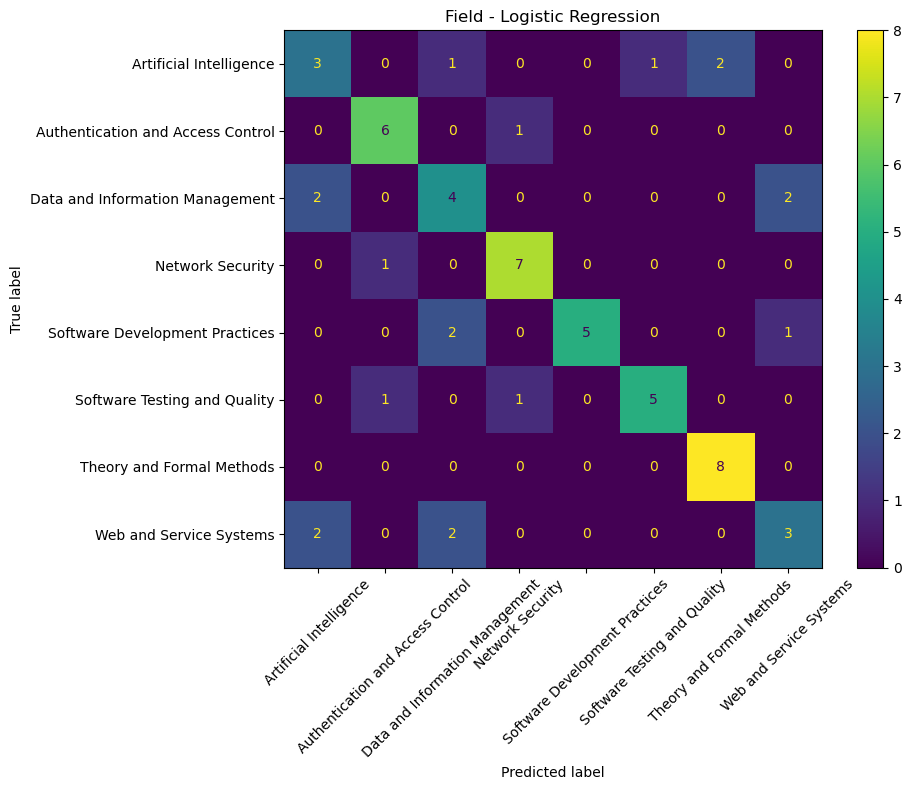

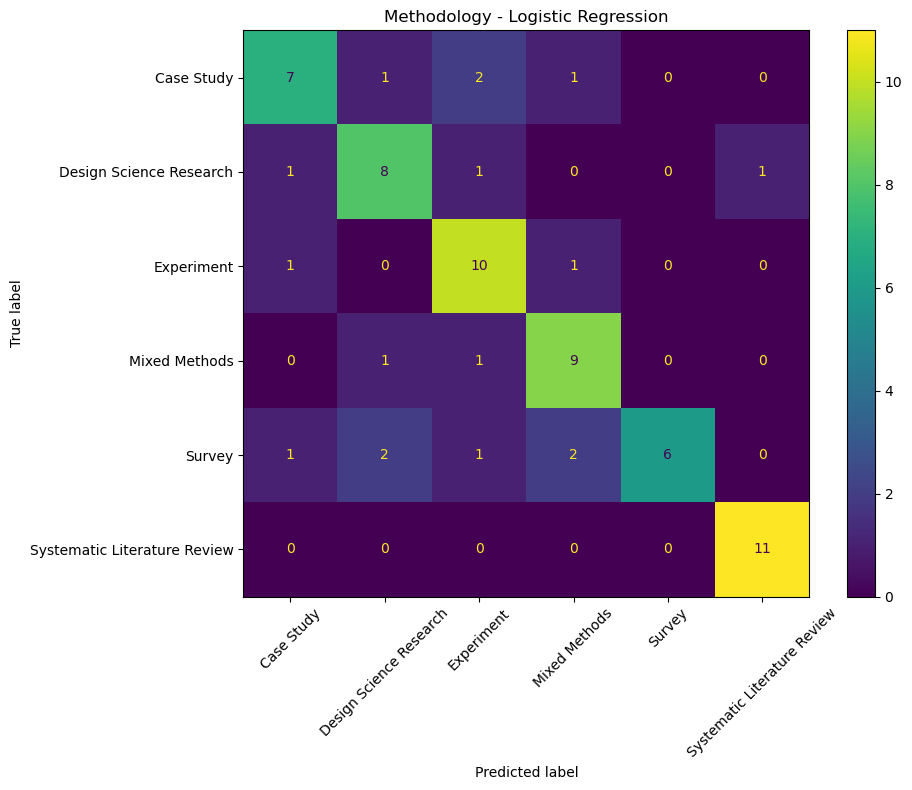

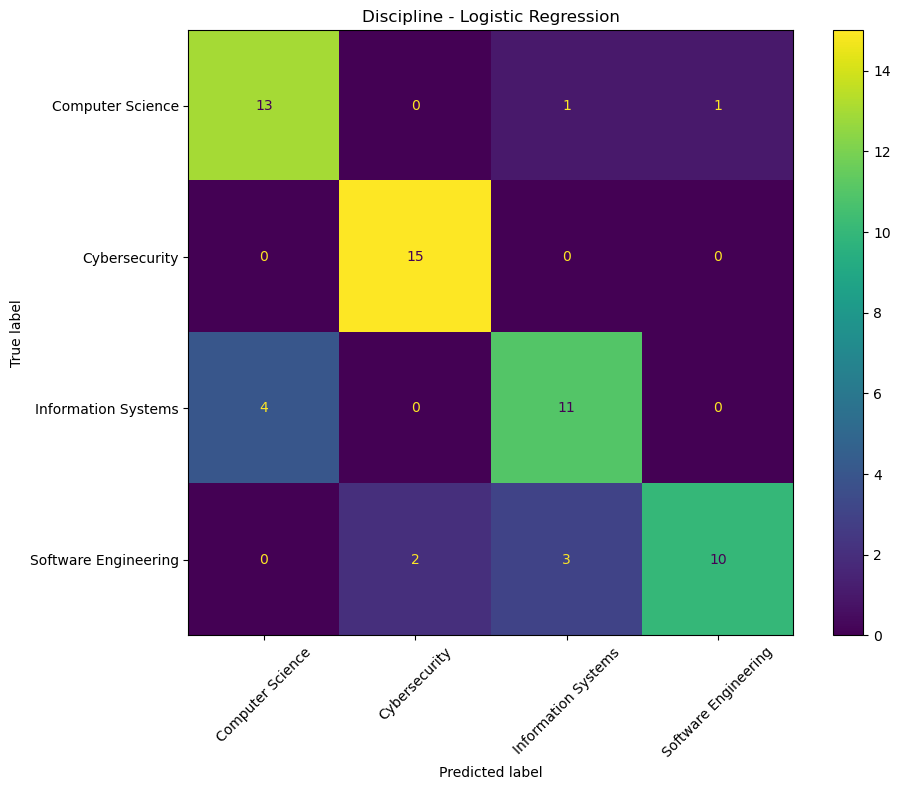

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,target
0,Logistic Regression,0.683333,0.691766,0.678571,0.676447,0.680555,Field
1,Naive Bayes,0.650000,0.650050,0.647321,0.645455,0.648888,Field
2,Dummy,0.116667,0.014583,0.125000,0.026119,0.024378,Field
3,Logistic Regression,0.816667,0.822371,0.816667,0.813141,0.813141,Discipline
4,Naive Bayes,0.816667,0.812449,0.816667,0.812279,0.812279,Discipline
5,Dummy,0.250000,0.062500,0.250000,0.100000,0.100000,Discipline
6,Logistic Regression,0.750000,0.773718,0.752525,0.746041,0.744796,Methodology
7,Naive Bayes,0.750000,0.773107,0.752525,0.745959,0.745135,Methodology
8,Dummy,0.161765,0.026961,0.166667,0.046414,0.045048,Methodology


In [6]:
subject_train_val = subject_df[
    subject_df["split"].isin(["train", "validation"])
].copy()

method_train_val = method_df[
    method_df["split"].isin(["train", "validation"])
].copy()

def evaluate_test_model(
    model,
    model_name,
    target_name,
    frame,
    text_column,
    label_column,
):
    predictions = model.predict(frame[text_column])
    probabilities = model.predict_proba(frame[text_column])
    confidence = probabilities.max(axis=1)

    metrics = metric_summary(
        frame[label_column],
        predictions,
    )

    report = pd.DataFrame(
        classification_report(
            frame[label_column],
            predictions,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()

    report.to_csv(
        REPORT_DIR / f"{target_name} {model_name} Test Report.csv",
        encoding="utf-8",
    )

    prediction_df = pd.DataFrame({
        "paper_id": frame["paper_id"].values,
        "true_label": frame[label_column].values,
        "predicted_label": predictions,
        "confidence": confidence,
        "correct": frame[label_column].values == predictions,
        "model": model_name,
        "target": target_name,
        "split": "test",
    })

    prediction_df.to_csv(
        PREDICTION_DIR / f"{target_name} {model_name} Test Predictions.csv",
        index=False,
        encoding="utf-8",
    )

    return metrics, prediction_df


def fit_and_test(
    train_val_df,
    test_df,
    text_column,
    label_column,
    target_name,
):
    rows = []
    predictions = {}
    models = {}

    for model_name in MODEL_NAMES:
        model = make_pipeline(model_name)
        model.fit(
            train_val_df[text_column],
            train_val_df[label_column],
        )

        metrics, prediction_df = evaluate_test_model(
            model,
            model_name,
            target_name,
            test_df,
            text_column,
            label_column,
        )

        models[model_name] = model
        predictions[model_name] = prediction_df
        rows.append({
            "model": model_name,
            **metrics,
        })

    results = (
        pd.DataFrame(rows)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    return results, predictions, models


field_test, field_predictions, field_models = fit_and_test(
    subject_train_val,
    subject_test,
    "model_text",
    "field",
    "Field",
)

methodology_test, methodology_predictions, methodology_models = fit_and_test(
    method_train_val,
    method_test,
    "methodology_text",
    "methodology",
    "Methodology",
)

discipline_rows = []
discipline_predictions = {}

for model_name, prediction_df in field_predictions.items():
    predicted_disciplines = prediction_df["predicted_label"].map(field_to_discipline)
    true_disciplines = subject_test["discipline"].reset_index(drop=True)

    metrics = metric_summary(
        true_disciplines,
        predicted_disciplines,
    )

    output = pd.DataFrame({
        "paper_id": subject_test["paper_id"].values,
        "true_label": true_disciplines.values,
        "predicted_label": predicted_disciplines.values,
        "correct": true_disciplines.values == predicted_disciplines.values,
        "model": model_name,
        "target": "Discipline",
        "split": "test",
    })

    output.to_csv(
        PREDICTION_DIR / f"Discipline {model_name} Test Predictions.csv",
        index=False,
        encoding="utf-8",
    )

    pd.DataFrame(
        classification_report(
            true_disciplines,
            predicted_disciplines,
            output_dict=True,
            zero_division=0,
        )
    ).transpose().to_csv(
        REPORT_DIR / f"Discipline {model_name} Test Report.csv",
        encoding="utf-8",
    )

    discipline_predictions[model_name] = output
    discipline_rows.append({
        "model": model_name,
        **metrics,
    })

discipline_test = (
    pd.DataFrame(discipline_rows)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

field_test.to_csv(
    RESULTS_DIR / "Field Test Results.csv",
    index=False,
    encoding="utf-8",
)

methodology_test.to_csv(
    RESULTS_DIR / "Methodology Test Results.csv",
    index=False,
    encoding="utf-8",
)

discipline_test.to_csv(
    RESULTS_DIR / "Discipline Test Results.csv",
    index=False,
    encoding="utf-8",
)

classical_results = pd.concat(
    [
        field_test.assign(target="Field"),
        discipline_test.assign(target="Discipline"),
        methodology_test.assign(target="Methodology"),
    ],
    ignore_index=True,
)

classical_results.to_csv(
    RESULTS_DIR / "Classical Test Results.csv",
    index=False,
    encoding="utf-8",
)

selected_field_predictions = field_predictions[selected["field"]]
selected_method_predictions = methodology_predictions[selected["methodology"]]
selected_discipline_predictions = discipline_predictions[selected["field"]]

save_confusion_matrix(
    selected_field_predictions["true_label"],
    selected_field_predictions["predicted_label"],
    sorted(subject_test["field"].unique()),
    f"Field - {selected['field']}",
    FIGURE_DIR / "Field Confusion Matrix.png",
)

save_confusion_matrix(
    selected_method_predictions["true_label"],
    selected_method_predictions["predicted_label"],
    sorted(method_test["methodology"].unique()),
    f"Methodology - {selected['methodology']}",
    FIGURE_DIR / "Methodology Confusion Matrix.png",
)

save_confusion_matrix(
    selected_discipline_predictions["true_label"],
    selected_discipline_predictions["predicted_label"],
    sorted(subject_test["discipline"].unique()),
    f"Discipline - {selected['field']}",
    FIGURE_DIR / "Discipline Confusion Matrix.png",
)

display(classical_results)

## Saving the selected pipelines

The selected Field and Methodology pipelines are saved with `joblib`, including their fitted TF-IDF vectorizers. 

Reloading a saved pipeline restores the trained representation and classifier (no need to fit them again).

In [7]:
field_model = field_models[selected["field"]]
methodology_model = methodology_models[selected["methodology"]]

joblib.dump(
    field_model,
    MODEL_DIR / "Field Model.joblib",
)

joblib.dump(
    methodology_model,
    MODEL_DIR / "Methodology Model.joblib",
)

settings = {
    "random_state": RANDOM_STATE,
    "field_model": selected["field"],
    "methodology_model": selected["methodology"],
    "selection_metric": "validation macro F1",
}

with (MODEL_DIR / "Classical Model Settings.json").open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(settings, f, indent=2)

display(pd.DataFrame([
    {
        "task": "Field",
        "saved model": selected["field"],
    },
    {
        "task": "Methodology",
        "saved model": selected["methodology"],
    },
]))

,task,saved model
0,Field,Logistic Regression
1,Methodology,Logistic Regression
